Customer Behavior Analytics & Churn Prediction

Teyzix Core Internship - Task DA-INT-1

Dataset: IBM Telco Customer Churn

Reference ID = TC-INT-20260602-358


1. Setup & Imports

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import shap

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
print('All libraries loaded.')

All libraries loaded.


2. Load & Inspect Data

In [7]:
df = pd.read_csv("C:/Users/daniy/Desktop/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
df.head()

Shape: (7043, 21)

Column types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\nDuplicates:')
print(f'{df.duplicated().sum()} duplicate rows')

print('\nTarget distribution:')
print(df['Churn'].value_counts())
print(f'Churn rate: {df["Churn"].eq("Yes").mean():.2%}')

Missing values:
Series([], dtype: int64)

Duplicates:


0 duplicate rows

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.54%


3. Data Cleaning

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# These are customers with tenure=0 (just joined), fill with MonthlyCharges
mask = df['TotalCharges'].isna()
print(f'Rows with missing TotalCharges: {mask.sum()}')
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges']

# Binary encode Churn & SeniorCitizen for later use
df['ChurnBinary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Droping customerID 
df.drop(columns=['customerID'], inplace=True)

df[['TotalCharges', 'MonthlyCharges', 'tenure']].describe()

Rows with missing TotalCharges: 11


,TotalCharges,MonthlyCharges,tenure
count,7043.000000,7043.000000,7043.000000
mean,2279.798992,64.761692,32.371149
std,2266.730170,30.090047,24.559481
min,18.800000,18.250000,0.000000
25%,398.550000,35.500000,9.000000
50%,1394.550000,70.350000,29.000000
75%,3786.600000,89.850000,55.000000
max,8684.800000,118.750000,72.000000


4. Exploratory Data Analysis

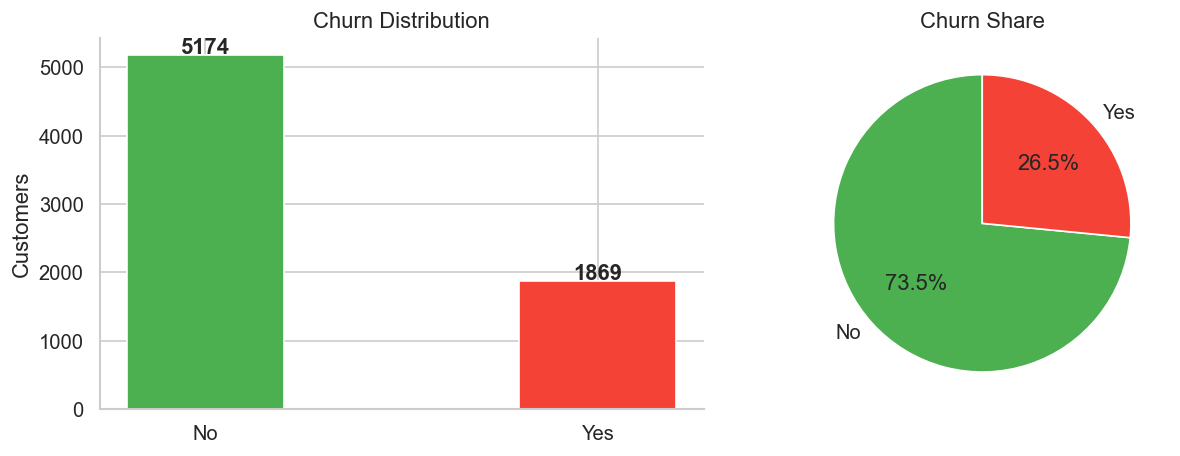

In [10]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['Churn'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors, width=0.4, edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Churn Share')

plt.tight_layout()
plt.savefig('viz_churn_distribution.png', bbox_inches='tight')
plt.show()

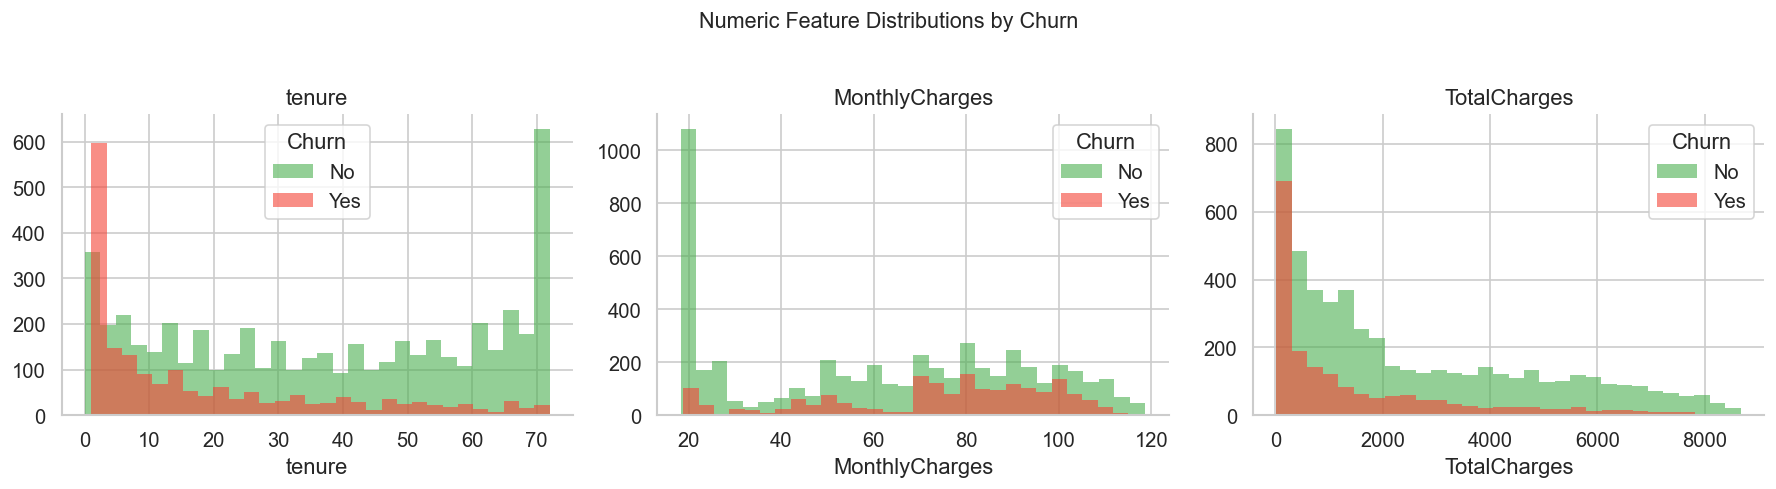

In [11]:
# Numeric distributions vs Churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby('Churn'):
        ax.hist(grp[col], bins=30, alpha=0.6,
                label=label, color='#F44336' if label == 'Yes' else '#4CAF50',
                edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend(title='Churn')

plt.suptitle('Numeric Feature Distributions by Churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('viz_numeric_distributions.png', bbox_inches='tight')
plt.show()

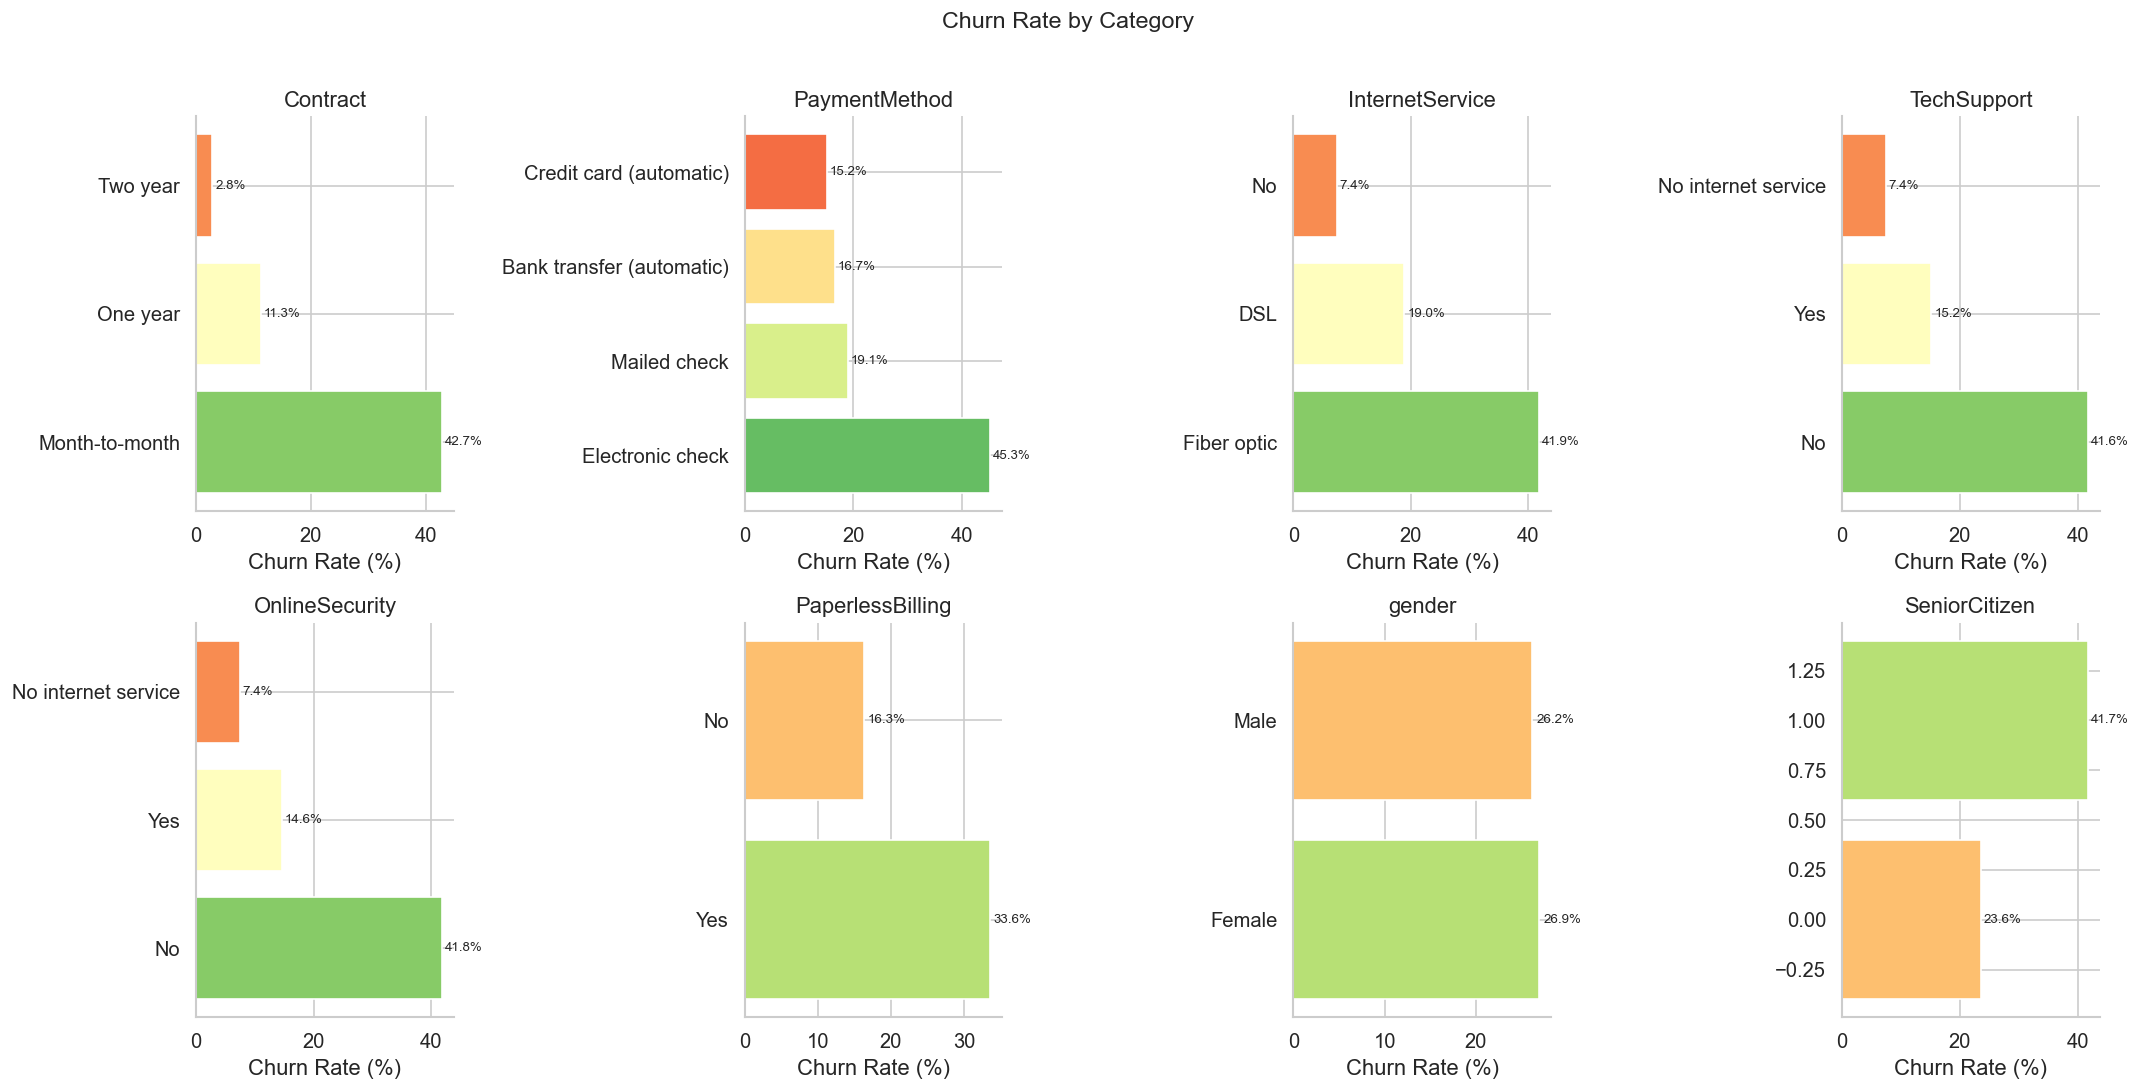

In [12]:
# Categorical churn rates
cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport',
            'OnlineSecurity', 'PaperlessBilling', 'gender', 'SeniorCitizen']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['ChurnBinary'].mean().sort_values(ascending=False)
    bars = ax.barh(churn_rate.index, churn_rate.values * 100,
                   color=sns.color_palette('RdYlGn_r', len(churn_rate)))
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(col)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(val * 100 + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1%}', va='center', fontsize=8)

plt.suptitle('Churn Rate by Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('viz_categorical_churn.png', bbox_inches='tight')
plt.show()

5. Feature Engineering

In [13]:
# Behavioral features

# Charge efficiency: higher means paying more per month relative to total spend
df['ChargeEfficiency'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

# Average monthly spend inferred from total / tenure
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Number of add-on services subscribed to
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServicesCount'] = df[service_cols].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1
)

# Tenure band: short / mid / long term customer
df['TenureBand'] = pd.cut(df['tenure'], bins=[0, 12, 36, 72],
                           labels=['Short', 'Mid', 'Long'], right=True)

# Month-to-month flag (highest risk contract)
df['IsMonthly'] = (df['Contract'] == 'Month-to-month').astype(int)

# Paperless and electronic check combo (known churn driver)
df['DigitalOnly'] = (
    (df['PaperlessBilling'] == 'Yes') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

# Engagement score: tenure * services (proxy for stickiness)
df['EngagementScore'] = df['tenure'] * df['ServicesCount']

print('New features created:')
new_feats = ['ChargeEfficiency', 'AvgMonthlySpend', 'ServicesCount',
             'TenureBand', 'IsMonthly', 'DigitalOnly', 'EngagementScore']
print(df[new_feats].describe())

New features created:
       ChargeEfficiency  AvgMonthlySpend  ServicesCount    IsMonthly  \
count       7043.000000      7043.000000    7043.000000  7043.000000   
mean           0.156206        59.055477       2.037910     0.550192   
std            0.276109        30.511795       1.847682     0.497510   
min            0.012596         9.183333       0.000000     0.000000   
25%            0.018091        26.175382       0.000000     0.000000   
50%            0.034860        61.025000       2.000000     1.000000   
75%            0.114266        84.830742       3.000000     1.000000   
max            0.990333       118.969863       6.000000     1.000000   

       DigitalOnly  EngagementScore  
count  7043.000000      7043.000000  
mean      0.247338        88.395002  
std       0.431495       117.366555  
min       0.000000         0.000000  
25%       0.000000         0.000000  
50%       0.000000        28.000000  
75%       0.000000       148.000000  
max       1.000000       

6. Customer Segmentation

                 Count  ChurnRate  AvgTenure  AvgMonthly  AvgServices
CustomerSegment                                                      
Low Value         2348       0.30      12.80       37.57         0.36
Medium Value      2347       0.31      29.98       64.27         1.78
High Value        2348       0.19      54.32       92.44         3.97


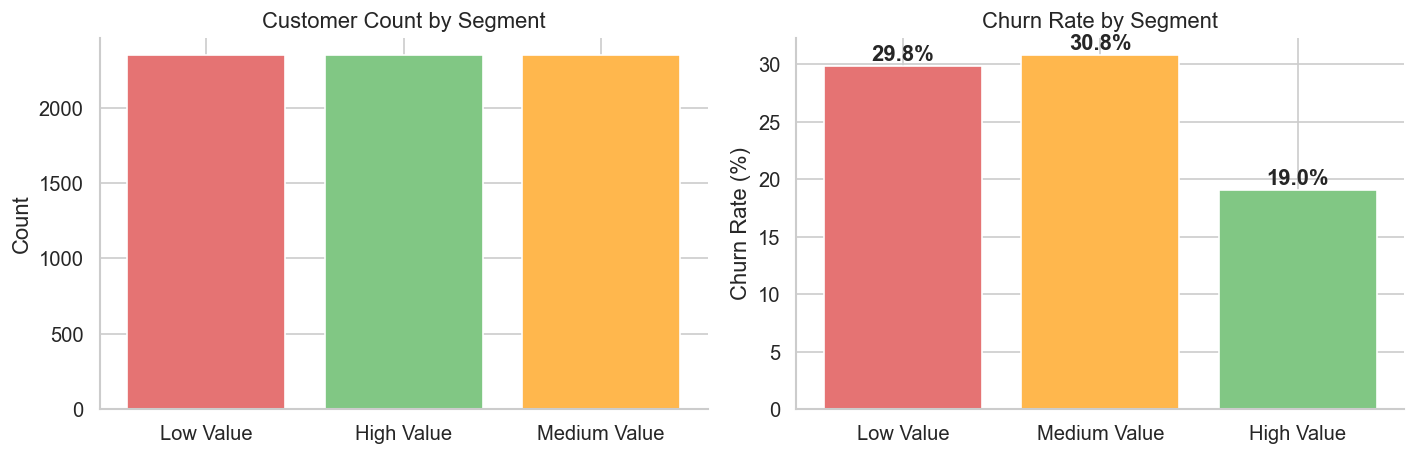

In [14]:
# Score based on tenure, spend, and services
df['ValueScore'] = (
    df['tenure'].rank(pct=True) * 0.4 +
    df['MonthlyCharges'].rank(pct=True) * 0.4 +
    df['ServicesCount'].rank(pct=True) * 0.2)

df['CustomerSegment'] = pd.qcut(
    df['ValueScore'], q=3,
    labels=['Low Value', 'Medium Value', 'High Value'])

seg_stats = df.groupby('CustomerSegment', observed=True).agg(
    Count=('ChurnBinary', 'count'),
    ChurnRate=('ChurnBinary', 'mean'),
    AvgTenure=('tenure', 'mean'),
    AvgMonthly=('MonthlyCharges', 'mean'),
    AvgServices=('ServicesCount', 'mean')).round(2)

print(seg_stats)

# Visualizing segment churn rates
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

palette = {'Low Value': '#E57373', 'Medium Value': '#FFB74D', 'High Value': '#81C784'}
seg_counts = df['CustomerSegment'].value_counts()
axes[0].bar(seg_counts.index, seg_counts.values,
            color=[palette[s] for s in seg_counts.index], edgecolor='white')
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Count')

churn_by_seg = df.groupby('CustomerSegment', observed=True)['ChurnBinary'].mean() * 100
bars = axes[1].bar(churn_by_seg.index, churn_by_seg.values,
                   color=[palette[s] for s in churn_by_seg.index], edgecolor='white')
axes[1].set_title('Churn Rate by Segment')
axes[1].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, churn_by_seg.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_customer_segments.png', bbox_inches='tight')
plt.show()

7. Correlation Heatmap

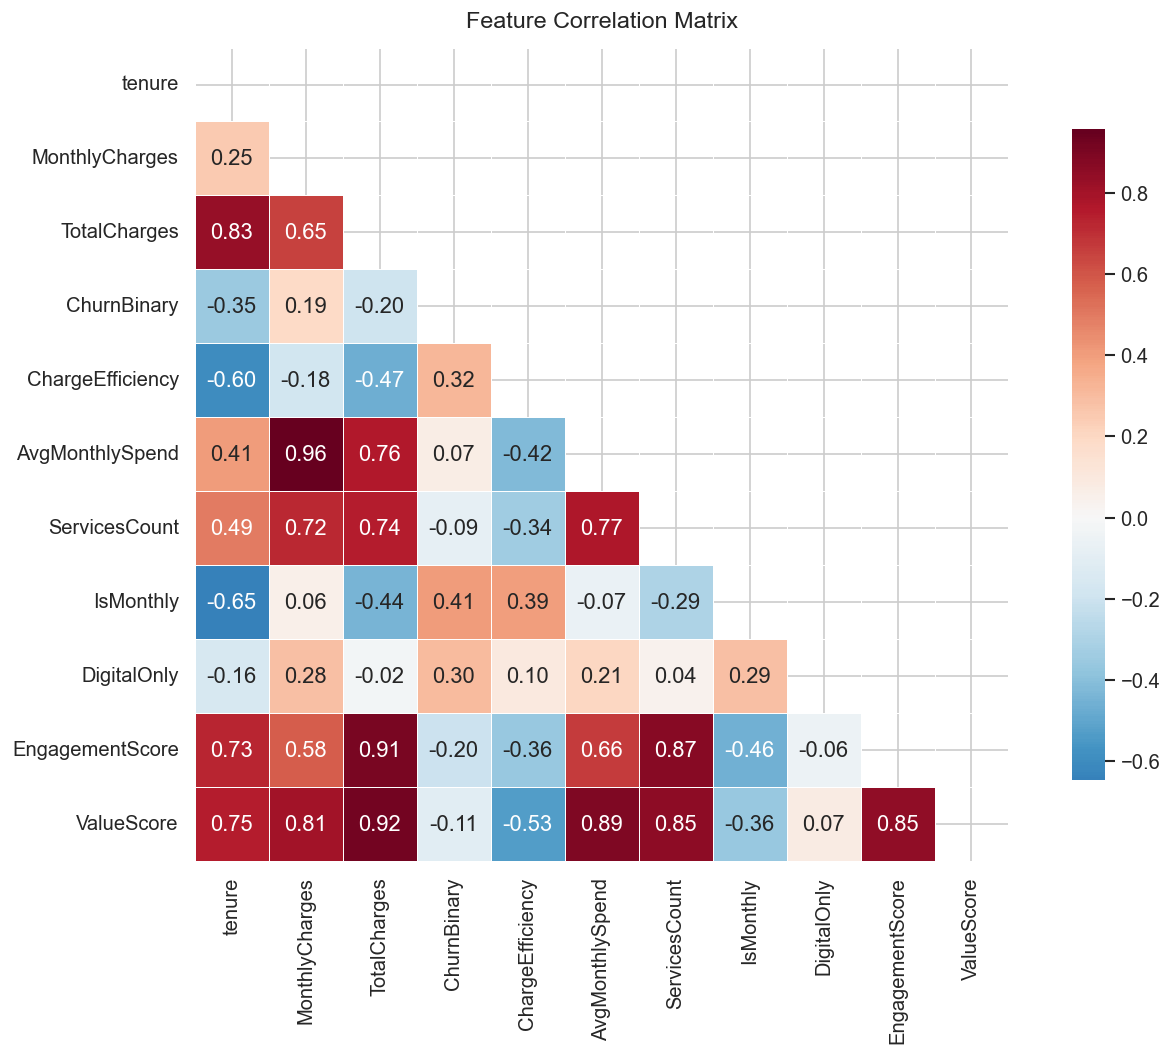

In [15]:
num_df = df.select_dtypes(include='number').drop(columns=['SeniorCitizen'])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('viz_correlation_heatmap.png', bbox_inches='tight')
plt.show()

8. Revenue Analysis

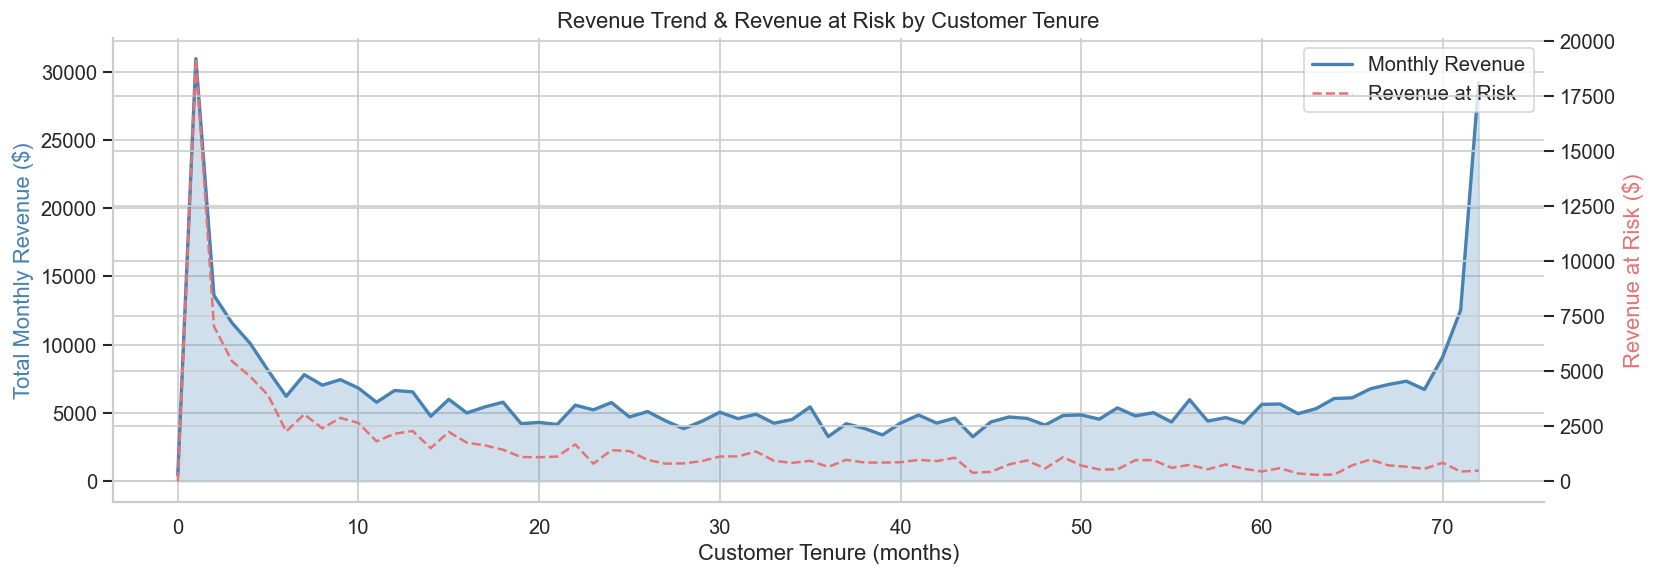

Total monthly revenue:        $456,117
Monthly revenue lost to churn: $139,131
Revenue impact:                30.5%


In [16]:
# Simulate revenue trend using tenure bins
df['TenureMonth'] = df['tenure']
monthly_rev = df.groupby('TenureMonth').agg(
    TotalRevenue=('MonthlyCharges', 'sum'),
    Customers=('ChurnBinary', 'count'),
    Churners=('ChurnBinary', 'sum')
).reset_index()
monthly_rev['RevenueAtRisk'] = monthly_rev['Churners'] / monthly_rev['Customers'] * monthly_rev['TotalRevenue']

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly_rev['TenureMonth'], monthly_rev['TotalRevenue'],
                 alpha=0.25, color='steelblue')
ax1.plot(monthly_rev['TenureMonth'], monthly_rev['TotalRevenue'],
         color='steelblue', linewidth=2, label='Monthly Revenue')
ax2.plot(monthly_rev['TenureMonth'], monthly_rev['RevenueAtRisk'],
         color='#E57373', linewidth=1.5, linestyle='--', label='Revenue at Risk')

ax1.set_xlabel('Customer Tenure (months)')
ax1.set_ylabel('Total Monthly Revenue ($)', color='steelblue')
ax2.set_ylabel('Revenue at Risk ($)', color='#E57373')
ax1.set_title('Revenue Trend & Revenue at Risk by Customer Tenure')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('viz_revenue_trend.png', bbox_inches='tight')
plt.show()

total_monthly = df['MonthlyCharges'].sum()
churn_revenue_loss = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
print(f'Total monthly revenue:        ${total_monthly:,.0f}')
print(f'Monthly revenue lost to churn: ${churn_revenue_loss:,.0f}')
print(f'Revenue impact:                {churn_revenue_loss/total_monthly:.1%}')

9. Preprocessing for ML

In [17]:
ml_df = df.copy()

# Droping columns not used in modelling
drop_cols = ['Churn', 'ChurnBinary', 'CustomerSegment', 'ValueScore', 'TenureMonth']
target = 'ChurnBinary'

# Re-adding target before dropping
ml_df[target] = df['ChurnBinary']
ml_df.drop(columns=[c for c in drop_cols if c != target], inplace=True)

# Encoding ordinal & nominal columns
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'IsMonthly', 'DigitalOnly']

for col in binary_cols:
    if col in ml_df.columns and ml_df[col].dtype == object:
        ml_df[col] = ml_df[col].map(binary_map).fillna(ml_df[col])

# One-hot encoding remaining categoricals
cat_cols = ml_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target]
print('One-hot encoding:', cat_cols)

ml_df = pd.get_dummies(ml_df, columns=cat_cols, drop_first=True)
ml_df = ml_df.astype(float)

X = ml_df.drop(columns=[target])
y = ml_df[target]

print(f'Feature matrix: {X.shape}  ,  Target: {y.shape}')
print(f'Class balance: {y.value_counts().to_dict()}')

One-hot encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureBand']
Feature matrix: (7043, 38)  ,  Target: (7043,)
Class balance: {0.0: 5174, 1.0: 1869}


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]}  ,  Test size: {X_test.shape[0]}')

Train size: 5634  ,  Test size: 1409


10. Model Training & Evaluation

In [19]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    results = {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_te, preds), 4),
        'Precision': round(precision_score(y_te, preds), 4),
        'Recall':    round(recall_score(y_te, preds), 4),
        'F1':        round(f1_score(y_te, preds), 4),
        'ROC-AUC':   round(roc_auc_score(y_te, proba), 4)}
    return results, proba


lr  = LogisticRegression(max_iter=1000, C=0.5, random_state=SEED)
rf  = RandomForestClassifier(n_estimators=300, max_depth=10,
                              min_samples_leaf=5, random_state=SEED, n_jobs=-1)
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     use_label_encoder=False, eval_metric='logloss',
                     random_state=SEED, n_jobs=-1)

lr_res,  lr_proba  = evaluate_model('Logistic Regression', lr,  X_train_sc, y_train, X_test_sc, y_test)
rf_res,  rf_proba  = evaluate_model('Random Forest',       rf,  X_train,    y_train, X_test,    y_test)
xgb_res, xgb_proba = evaluate_model('XGBoost',            xgb, X_train,    y_train, X_test,    y_test)

results_df = pd.DataFrame([lr_res, rf_res, xgb_res])
results_df.set_index('Model', inplace=True)
print(results_df.to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.8041     0.6591  0.5428  0.5953   0.8478
Random Forest          0.7999     0.6523  0.5267  0.5828   0.8455
XGBoost                0.7892     0.6238  0.5187  0.5664   0.8350


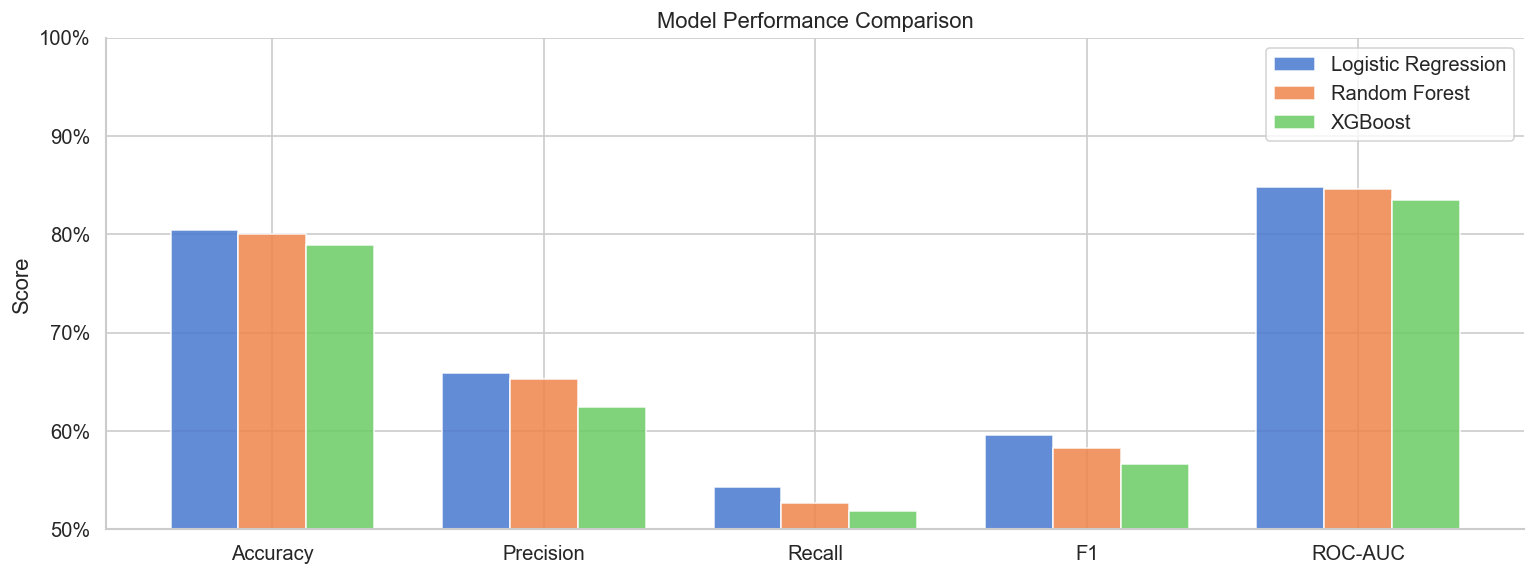

In [20]:
# Model comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, row[metrics], width,
                  label=name, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('Viz Model Comparison.png', bbox_inches='tight')
plt.show()

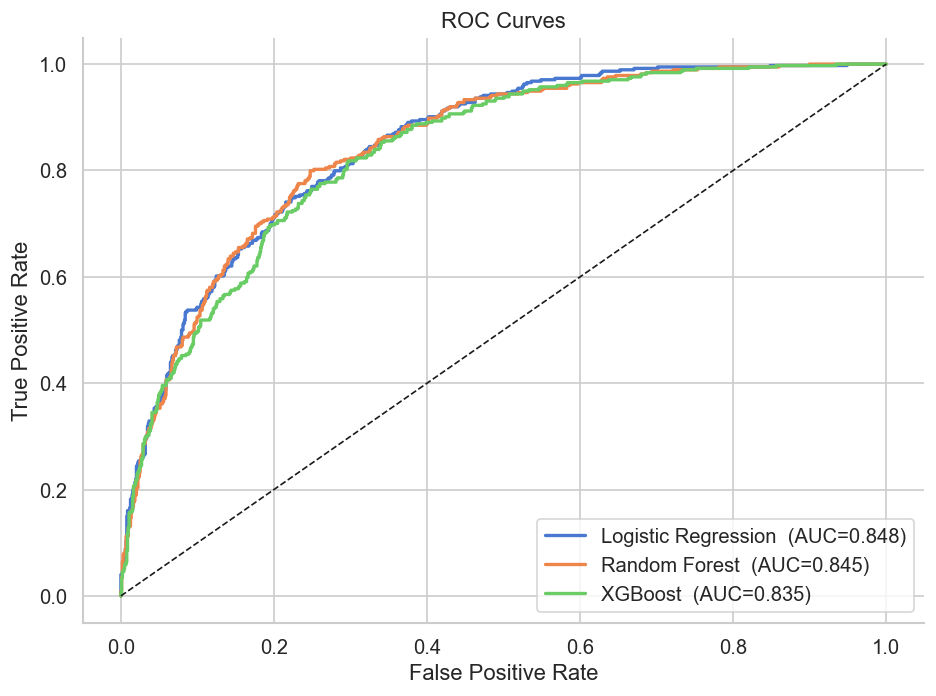

In [21]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in [('Logistic Regression', lr_proba),
                     ('Random Forest', rf_proba),
                     ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Viz Roc Curves.png', bbox_inches='tight')
plt.show()

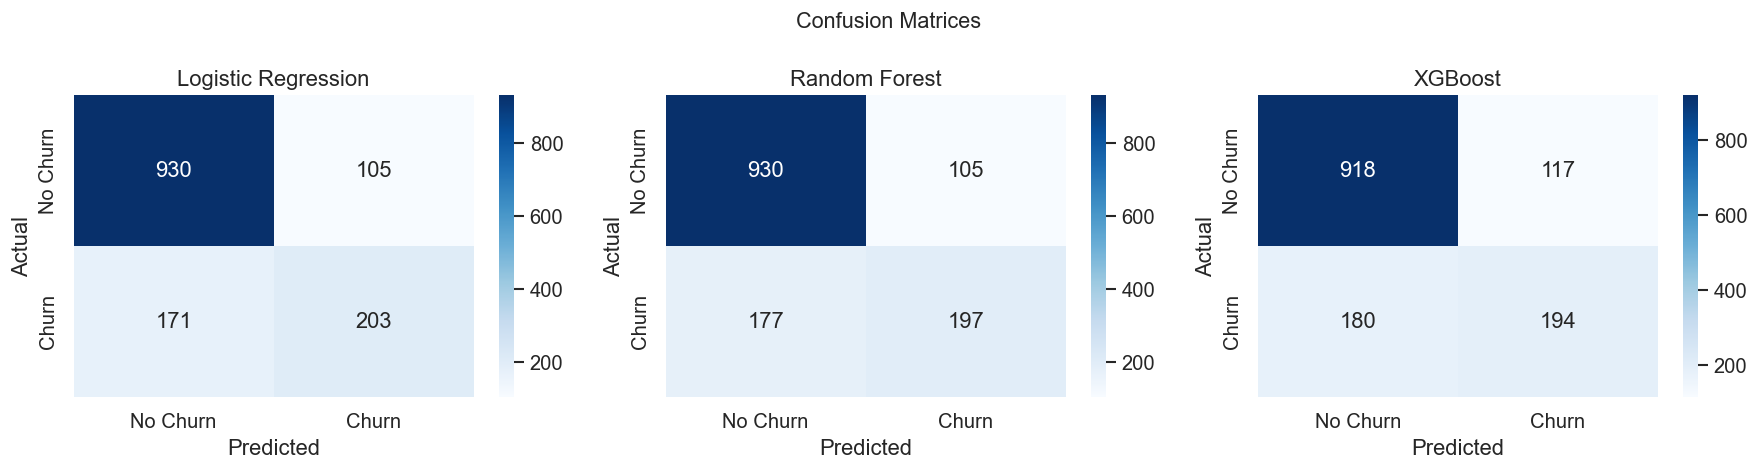

In [22]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model, Xte, proba) in zip(axes, [
    ('Logistic Regression', lr, X_test_sc, lr_proba),
    ('Random Forest',       rf, X_test,    rf_proba),
    ('XGBoost',            xgb, X_test,    xgb_proba)
]):
    cm = confusion_matrix(y_test, model.predict(Xte))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('Viz Confusion Matrices.png', bbox_inches='tight')
plt.show()

11. Feature Importance & SHAP

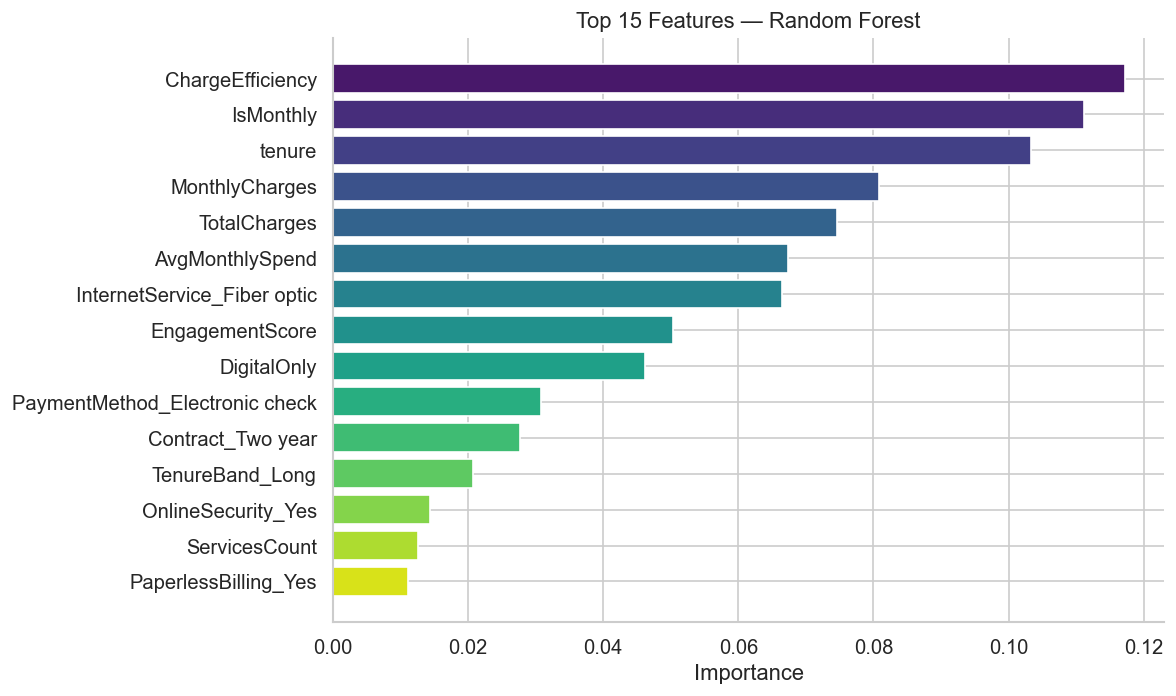

In [23]:
# Random Forest feature importance
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = fi.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('viridis', len(top15))
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel('Importance')
ax.set_title('Top 15 Features — Random Forest')
plt.tight_layout()
plt.savefig('Viz Feature Importance.png', bbox_inches='tight')
plt.show()

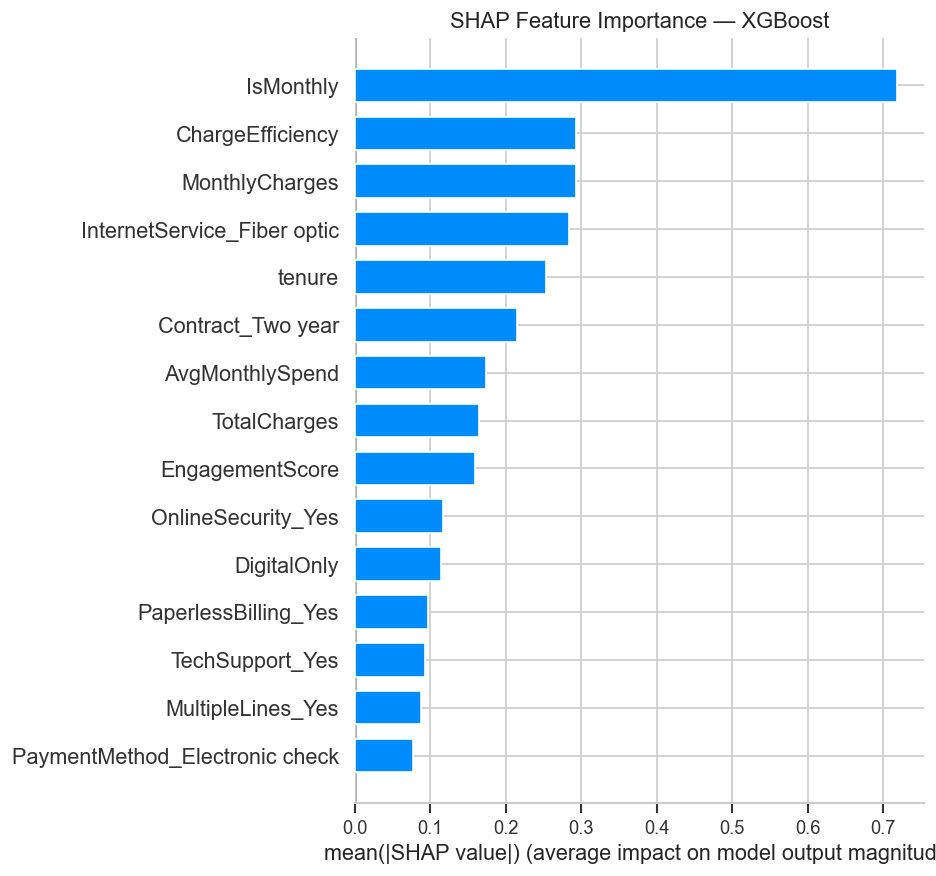

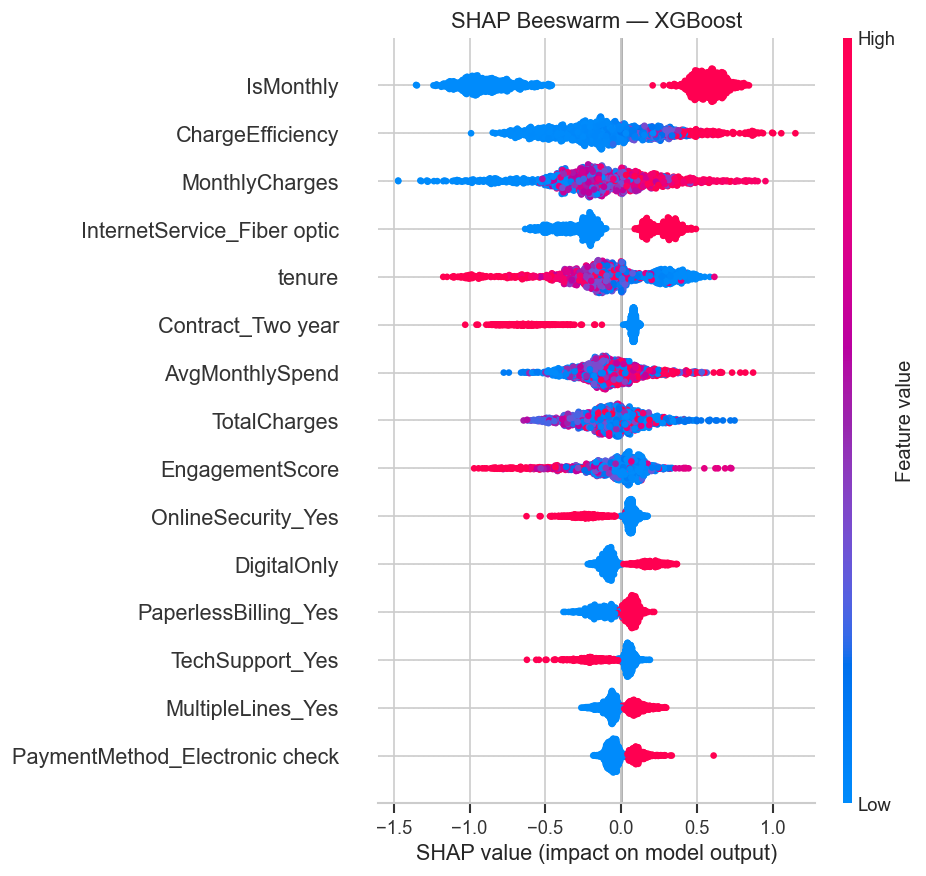

In [24]:
# SHAP explainability on XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('viz_shap_importance.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Beeswarm — XGBoost')
plt.tight_layout()
plt.savefig('Viz Shap Beeswarm.png', bbox_inches='tight')
plt.show()

12. Churn Probability & Risk Categorisation

RiskCategory
Low Risk       4765
Medium Risk    1255
High Risk      1023
Name: count, dtype: int64


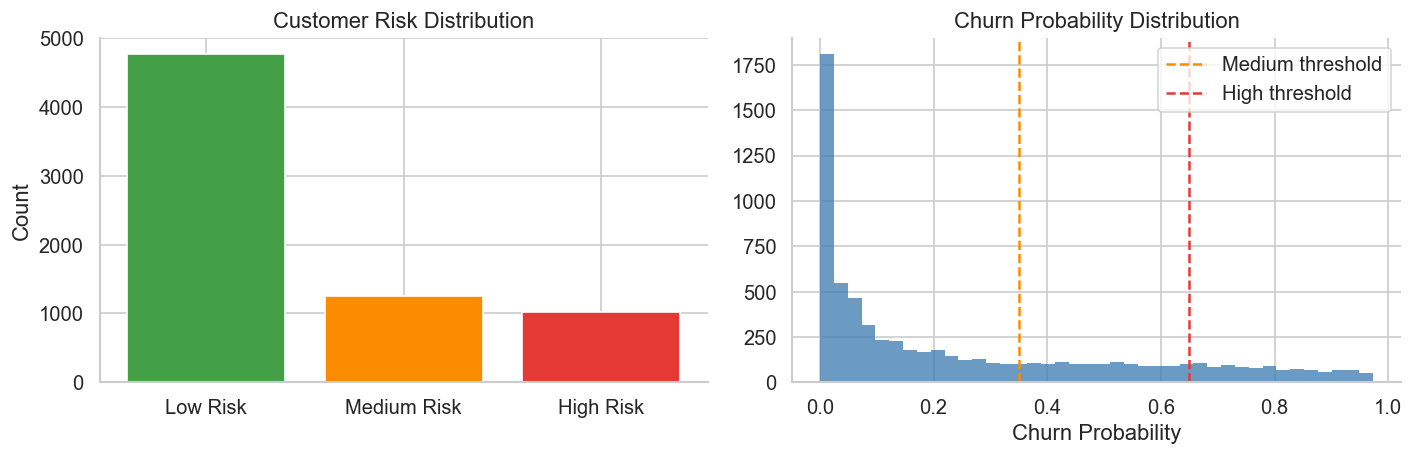

In [25]:
# Use best model (XGBoost) for final predictions
df_out = df.copy()
df_out['ChurnProba'] = xgb.predict_proba(X)[:, 1]

def risk_label(p):
    if p >= 0.65:
        return 'High Risk'
    elif p >= 0.35:
        return 'Medium Risk'
    return 'Low Risk'

df_out['RiskCategory'] = df_out['ChurnProba'].apply(risk_label)

risk_counts = df_out['RiskCategory'].value_counts()
print(risk_counts)

# Risk category distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

risk_colors = {'High Risk': '#E53935', 'Medium Risk': '#FB8C00', 'Low Risk': '#43A047'}
axes[0].bar(risk_counts.index, risk_counts.values,
            color=[risk_colors[r] for r in risk_counts.index], edgecolor='white')
axes[0].set_title('Customer Risk Distribution')
axes[0].set_ylabel('Count')

axes[1].hist(df_out['ChurnProba'], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0.35, color='#FB8C00', linestyle='--', linewidth=1.5, label='Medium threshold')
axes[1].axvline(0.65, color='#E53935', linestyle='--', linewidth=1.5, label='High threshold')
axes[1].set_title('Churn Probability Distribution')
axes[1].set_xlabel('Churn Probability')
axes[1].legend()

plt.tight_layout()
plt.savefig('Viz Risk Distribution.png', bbox_inches='tight')
plt.show()

In [26]:
# High-risk customer profile
high_risk = df_out[df_out['RiskCategory'] == 'High Risk']
low_risk  = df_out[df_out['RiskCategory'] == 'Low Risk']

print('=== HIGH RISK vs LOW RISK PROFILE ===')
compare_cols = ['tenure', 'MonthlyCharges', 'ServicesCount',
                'IsMonthly', 'DigitalOnly', 'EngagementScore']
comparison = pd.DataFrame({
    'High Risk Avg': high_risk[compare_cols].mean(),
    'Low Risk Avg':  low_risk[compare_cols].mean()
}).round(2)
print(comparison)

=== HIGH RISK vs LOW RISK PROFILE ===
                 High Risk Avg  Low Risk Avg
tenure                   11.15         40.10
MonthlyCharges           80.97         59.52
ServicesCount             1.68          2.21
IsMonthly                 0.98          0.37
DigitalOnly               0.63          0.12
EngagementScore          28.91        110.49


13. Business Insights Report

In [27]:
churn_rev = df_out[df_out['Churn'] == 'Yes']['MonthlyCharges'].sum()
total_rev  = df_out['MonthlyCharges'].sum()
high_risk_rev = df_out[df_out['RiskCategory'] == 'High Risk']['MonthlyCharges'].sum()


print('BUSINESS INSIGHTS REPORT — TELCO CHURN')


print(f"""
OVERVIEW
  Total customers:          {len(df_out):,}
  Churned customers:        {df_out['Churn'].eq('Yes').sum():,}  ({df_out['Churn'].eq('Yes').mean():.1%})
  Monthly revenue:          ${total_rev:,.0f}
  Revenue lost (churn):     ${churn_rev:,.0f} / month
  Revenue at risk (HR):     ${high_risk_rev:,.0f} / month

TOP CHURN DRIVERS
  1. Month-to-month contracts   = churn rate ~42%
  2. Electronic check payment   = highest payment method churn
  3. Fiber optic without extras = paying more, getting less
  4. Low tenure (<12 months)    = still in the decision window
  5. No tech support / security = dissatisfied service experience

HIGH-RISK CUSTOMER TRAITS
  • Short tenure (avg < 10 months)
  • Month-to-month contract
  • Electronic check + paperless billing
  • Fewer bundled services
  • High monthly charge relative to total spend

SEGMENT SUMMARY
""")
print(seg_stats.to_string())

print(f"""
MODEL RESULTS
""")
print(results_df.to_string())

print(f"""
RECOMMENDATIONS
  1. Priority retention: target high-risk customers with churn
     probability ≥ 0.65 — {len(high_risk):,} customers identified.
  2. Incentivise annual/2-year contracts with a discount offer.
  3. Onboarding bundles for new customers (<6 months tenure).
  4. Auto-pay setup incentive to shift from electronic check.
  5. Proactive tech-support outreach for fiber customers.
""")


BUSINESS INSIGHTS REPORT — TELCO CHURN

OVERVIEW
  Total customers:          7,043
  Churned customers:        1,869  (26.5%)
  Monthly revenue:          $456,117
  Revenue lost (churn):     $139,131 / month
  Revenue at risk (HR):     $82,830 / month

TOP CHURN DRIVERS
  1. Month-to-month contracts   = churn rate ~42%
  2. Electronic check payment   = highest payment method churn
  3. Fiber optic without extras = paying more, getting less
  4. Low tenure (<12 months)    = still in the decision window
  5. No tech support / security = dissatisfied service experience

HIGH-RISK CUSTOMER TRAITS
  • Short tenure (avg < 10 months)
  • Month-to-month contract
  • Electronic check + paperless billing
  • Fewer bundled services
  • High monthly charge relative to total spend

SEGMENT SUMMARY

                 Count  ChurnRate  AvgTenure  AvgMonthly  AvgServices
CustomerSegment                                                      
Low Value         2348       0.30      12.80       37.57       

In [28]:
# Export scored customer file
export_cols = ['gender', 'SeniorCitizen', 'tenure', 'Contract',
               'MonthlyCharges', 'TotalCharges', 'Churn',
               'CustomerSegment', 'ChurnProba', 'RiskCategory']
df_out[export_cols].to_csv('Customer Risk Scores.csv', index=False)
print('Exported: Customer Risk Scores.csv')

Exported: Customer Risk Scores.csv
